In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("C:/Users/Prathmesh Ingole/Downloads/lemma_industry_grade_doooh_dataset.csv")
df

,CampaignID,Client,Industry,City,ScreenType,AdType,Impressions,Clicks,CTR,Spend_INR,...,weather_condition,time_slot,adjusted_impressions,cpm,revenue,ad_spend,roi_percent,click_through_rate,estimated_clicks,campaign_performance
0,C0001,Pepsi,Retail,Hyderabad,Metro Screen,Programmatic,438323,20025,4.57,404785,...,Sunny,Morning,22718,102.10,2319.51,1552.91,49.37,4.53,1029,High Performing
1,C0002,OnePlus,Entertainment,Pune,Outdoor Billboard,Video,365631,4044,1.11,314951,...,Sunny,Evening,8423,328.51,2767.04,1956.50,41.43,5.32,448,Moderate
2,C0003,Boat,Entertainment,Bangalore,Shopping Mall Screen,Image,472481,7742,1.64,447833,...,Rainy,Evening,44236,295.42,13068.20,11364.52,14.99,4.48,1981,Low Performing
3,C0004,Netflix,Technology,Delhi,Metro Screen,Programmatic,100707,2453,2.44,249191,...,Foggy,Evening,46623,446.38,20811.57,12825.91,62.26,1.78,829,High Performing
4,C0005,Paytm,Technology,Pune,Shopping Mall Screen,HTML,339428,7374,2.17,91313,...,Sunny,Evening,23408,168.49,3944.01,2176.14,81.24,4.38,1025,High Performing
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,C0996,Apple,Fintech,Mumbai,Airport Screen,HTML,161707,1631,1.01,188805,...,Rainy,Night,7466,153.44,1145.58,852.13,34.44,4.54,338,Moderate
996,C0997,OnePlus,Entertainment,Bangalore,Airport Screen,Programmatic,494780,14611,2.95,373878,...,Rainy,Evening,48002,141.01,6768.76,4938.10,37.07,5.12,2457,Moderate
997,C0998,Nike,Audio Tech,Ahmedabad,Airport Screen,HTML,233354,10642,4.56,52702,...,Sunny,Night,28596,168.80,4827.00,3130.25,54.20,3.50,1000,High Performing
998,C0999,Adidas,Food,Pune,Outdoor Billboard,HTML,327398,10009,3.06,94430,...,Sunny,Evening,40717,342.75,13955.75,11691.85,19.36,0.98,399,Low Performing


define Features and target

In [15]:
X=df.drop('campaign_performance',axis=1)
y=df['campaign_performance']

In [16]:
from sklearn.preprocessing import  LabelEncoder

le_dict={}

for col in X.select_dtypes(include='object').columns:
        le=LabelEncoder()
        X[col]=le.fit_transform(X[col])
        le_dict[col]=le
        
y=LabelEncoder().fit_transform(y)


In [17]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CampaignID              1000 non-null   int64  
 1   Client                  1000 non-null   int64  
 2   Industry                1000 non-null   int64  
 3   City                    1000 non-null   int64  
 4   ScreenType              1000 non-null   int64  
 5   AdType                  1000 non-null   int64  
 6   Impressions             1000 non-null   int64  
 7   Clicks                  1000 non-null   int64  
 8   CTR                     1000 non-null   float64
 9   Spend_INR               1000 non-null   int64  
 10  ScreenTime_HoursPerDay  1000 non-null   int64  
 11  RunningTime_Hours       1000 non-null   int64  
 12  Duration_days           1000 non-null   int64  
 13  AudienceType            1000 non-null   int64  
 14  Date                    1000 non-null   i

In [18]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

Train Random Forest

In [19]:
from sklearn.ensemble import RandomForestClassifier

model=RandomForestClassifier(n_estimators=100,
                            random_state=42)
model.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [41]:
#make prediction
y_pred=model.predict(X_test)

In [26]:
# evaluate model

from sklearn.metrics  import accuracy_score

accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)

Accuracy: 1.0


In [27]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        96
           1       1.00      1.00      1.00        29
           2       1.00      1.00      1.00        75

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



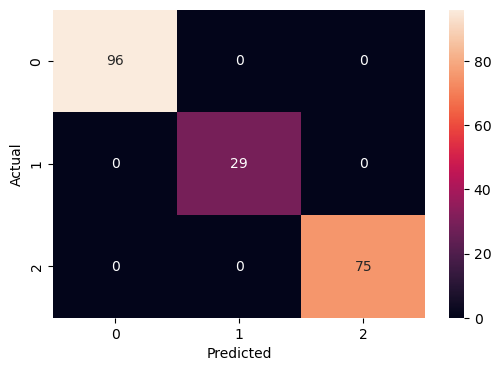

In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm=confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True,fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [32]:
import pandas as pd

importance=pd.DataFrame({
    'feature':X.columns,
    'Importance':model.feature_importances_
})
importance=importance.sort_values(by='Importance',ascending=False)
print(importance.head(10))

                 feature  Importance
24           roi_percent    0.669005
23              ad_spend    0.032778
22               revenue    0.023779
17             screen_id    0.019002
16           impressions    0.017141
21                   cpm    0.017041
14                  Date    0.016757
20  adjusted_impressions    0.016431
9              Spend_INR    0.015691
26      estimated_clicks    0.015125


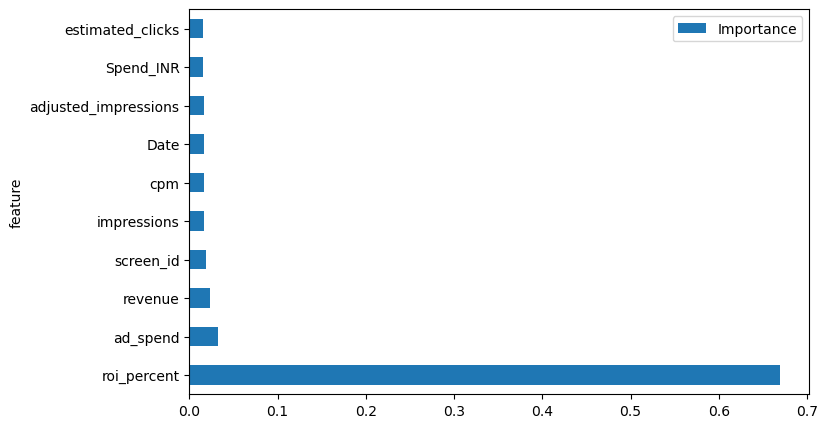

In [39]:
importance.head(10).plot(
    x='feature',
    y='Importance',
    kind='barh',
    figsize=(8,5)
)
plt.show()